# Learn Machine Learning: A Tutorial for Python Programmers

 ##  Preprocessing

## Step 1: Read the Data

Machine Learning with Python is often done with three main libraries. The numpy library, which allows data to be stored in matricies (numpy arrays), so that they can be reshaped as needed and fed into regression models as is. 2) The pandas library, which is built on top of the numpy library, contains several functions that allow the data analyst to see the data set in a format similar to R and excel presentations. Additionally, besides being able to keep track of the data on an attribute by name basis, pandas has several functions which can tell us the class distribution of the the data etc. Finally the scientific matplotlib library is useful for plotting and has extensions such as the Pearson and Seaborn libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
dataset = pd.read_csv('blooddataset.csv') 

## Step 2: Type Checking

In [2]:
#See the first 5 and last 5 rows within the dataframe
dataset.head() #MAYBE CHANGE INDEX TO 0

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [3]:
dataset.tail()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
743,23,2,500,38,0
744,21,2,500,52,0
745,23,3,750,62,0
746,39,1,250,39,0
747,72,1,250,72,0


In [4]:
type(dataset)

pandas.core.frame.DataFrame

In [5]:
dataset.shape

(748, 5)

In [6]:
type(dataset['whether he/she donated blood in March 2007'])

pandas.core.series.Series

In [8]:
type(dataset['Recency (months)'])

pandas.core.series.Series

In [8]:
Frequency (times)

NameError: name 'Frequency' is not defined

In [ ]:
Monetary (c.c. blood)

In [ ]:
Time (months)

Conclusion: We have ensured that our data set has no missing values and that all our features are of the same type. However, we have found one interesting discovery. The units of our data are not the same. The 'Monetary' column runs in the triple digit range while our other columns are single or double digits. This conflicting scale can cause responsible a disproportionate visualization (and therefore meaningless) we saw with our graph and would also produce erroneous results since our machine learning models would assume that all data is within the same scale. Fortunately, a library function in the scikit learn library can automatically scale all our attributes for us! This sub-step will be performed in the coming steps before we apply a machine learning algorithm.

## Step 3: Visualize The Data with Seaborn (use boxplot)

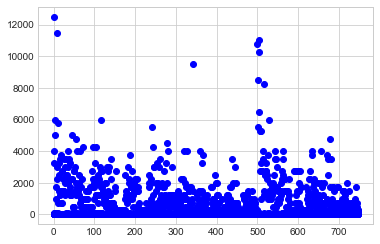

In [9]:
plt.style.use('seaborn-whitegrid')
plt.plot(dataset,'bo');

## Step 4: Exploratory Analysis

**We now have a visual of our data. At this point it is possible to run a learning algorithm. However, such a move would be premature. We could definetly narrow our choice of algorithm down to classification instead of regression, since the response variable (the target feature from the dataframe output a few cells above) has categorical classes (type of response varaibles), but beyond that we have no information besides pure guesswork. So far we have 
-imported the dataset
-visualized the data to get a feel for it
-check type (so we know which data structure the data is held in) 
convert to pandas dataframe, there are other options, but python's pandas library is a great and widely used tool
that 
-print either your entire dataset, or .head() and .tail() to show the first 5 and last 5 records respectively
-ask yourself, what are the features, what do they represent? Which column is the target or response attribute? Is the response
attribte discrete or continuous, text or numerical? Decide if you will use regression or classification. What does each record
signify? (ex 200 cancer patients, 400 employees that took time off in December, etc)

Whenever you read a statistic or study online, a correlation is presented usually between one or just a couple of variables and a response variable that is associated with the former variables. Note we use the term correlation and not causation, as all our algorithms simpy tell us

In [10]:
from sklearn.cluster import KMeans

Instantiate a kmeans object and choose a value of k. Since we have two class variables of the response/target feature, we will choose a value of two; so two clusters.

In [11]:
kmeans = KMeans(n_clusters=2)
#n_clusters --- Number of clusters that we are looking for
#Change number of clusters to see how they change the results

Now let us identfiy the dataset's into a matrix of features and an independent vector. Since clustering algorithms are unsupervised learning, we will not use train/test split. Since we can see from the dataset that the last column is likely a target, we will split the others and train k-means on them (since the last feature is likely simply a class label)

In [12]:
X = dataset[['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)','Time (months)']]
y = dataset[['whether he/she donated blood in March 2007']]

In [13]:
kmeans.fit(X)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=2, n_init=10, n_jobs=1, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

We can see in the parameters output that kmeans++ was ran by default and 2 clusters for formed. (Kmeans++ having run means that the algorithm is repeated to ensure that our choice of k doesn't fall into the random intialization trap)

Let's print out the centroids and labels.

In [14]:
kmeans.cluster_centers_

array([[6.66666667e+00, 1.57863248e+01, 3.94658120e+03, 6.27692308e+01],
       [1.00332805e+01, 3.61014263e+00, 9.02535658e+02, 2.90000000e+01]])

The distances are not overly large. So it seems the clustering is well perfomed.

In [15]:
kmeans.labels_

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,

Success, our hypothesis was correct, there are indeed only 2 clusters; of 0 and 1. Which is the number of class variables in the last feature of the dataset; whether or not blood was donated.

#### Now we will also perform hierarichal clustering. With two types of clustering algorithms, we will have a very accurate breakdown of our model's clusters.

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
#We can either use single linkage (euclidean distance of the closest points of the clusters in the dendrogram)
#or complete linkage (distance of furthest points of the clusters in the dendrogram)
mergings = linkage(X, method='single') #chose single linkage #pass in our matrix of features as the first parameter
#and what HC will merge on (we are using agglomerative HC)

Plot the result of HC, our dendrogram. However, recall that in order to run HC, we need a scaled dataset. We discovered in steps 2-3, that our dataset was not scaled. Let us first run feature scaling and then plot the dendrogram of HC.

In [26]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

Posible scenario (**General Note: N/A in this scenario**)
*Why Scaling of y-vector may be Excluded*:
When we feature scale the response variable, it is no longer treated as a cateogrical
variable which has been encoded by onehotencoder, rather as a continous numeric variable since the independent variables of 
the data set are also continous variables-but this remains a classification problem since the response variable is continous

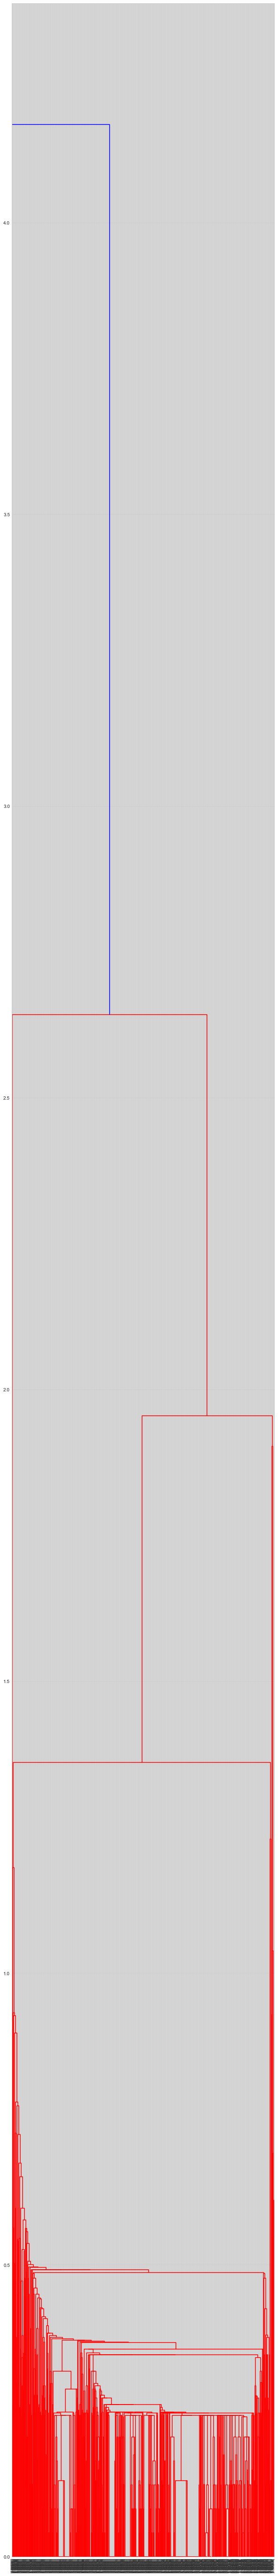

In [27]:
plt.figure(figsize=(10, 100))
dendrogram(mergings,
           labels=y,
)
plt.show()

It is not necessary to also run HC and fit the model on our data set. The goal of this stage was simply to explore our data, and the dendrograms as well as kmeans_labels functions did exactly that. Now, it is time to move on to the next step, in which we will try to reduce the features of our dataset and any noise that accompanies features which do not add to the analysis or have any impact on the correleations.

## Step 5: Feature Elimination- Reducing the noise of our data

In [28]:
#Decision Tree Fast Learning Scheme

In [14]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()

In [15]:
X = dataset[['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)', 'Time (months)']].values
y = dataset[['whether he/she donated blood in March 2007']].values

In [16]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [17]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

C:\Users\Primary\Anaconda3\lib\site-packages\sklearn\utils\validation.py:475: DataConversionWarning: Data with input dtype int64 was converted to float64 by StandardScaler.
  warnings.warn(msg, DataConversionWarning)


In [18]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [19]:
y_dtree = dtree.predict(X_test)
#NO EVALUATION, NOT RUNNING ALGORITHM TO LEARN, BUT TO REDUCE FEATURES

In [38]:
#Value count function of pandas tells you the quanitity of each value
#in a panda series
#examine the class distribution of the testing set (using a Pandas Series method)
#y_test.shape

### Visualizing Our Decision Tree

In [21]:
import graphviz 
from sklearn import tree

In [22]:
dot_data = tree.export_graphviz(dtree, out_file=None) 
graph = graphviz.Source(dot_data) 
graph.render("dataset") 

'dataset.pdf'

In [23]:
print(dataset.columns)
#removing the class variable
features = np.delete(dataset.columns, 4) #last index is our response and should show up as a leaf where tree ends
features

Index(['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)',
       'Time (months)', 'whether he/she donated blood in March 2007'],
      dtype='object')


Index(['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)',
       'Time (months)'],
      dtype='object')

In [24]:
target_names = np.array(list(set(dataset.values[:,0]))).astype(str)
target_names

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '20', '21', '22', '23', '25',
       '26', '35', '38', '39', '40', '72', '74'], dtype='<U21')

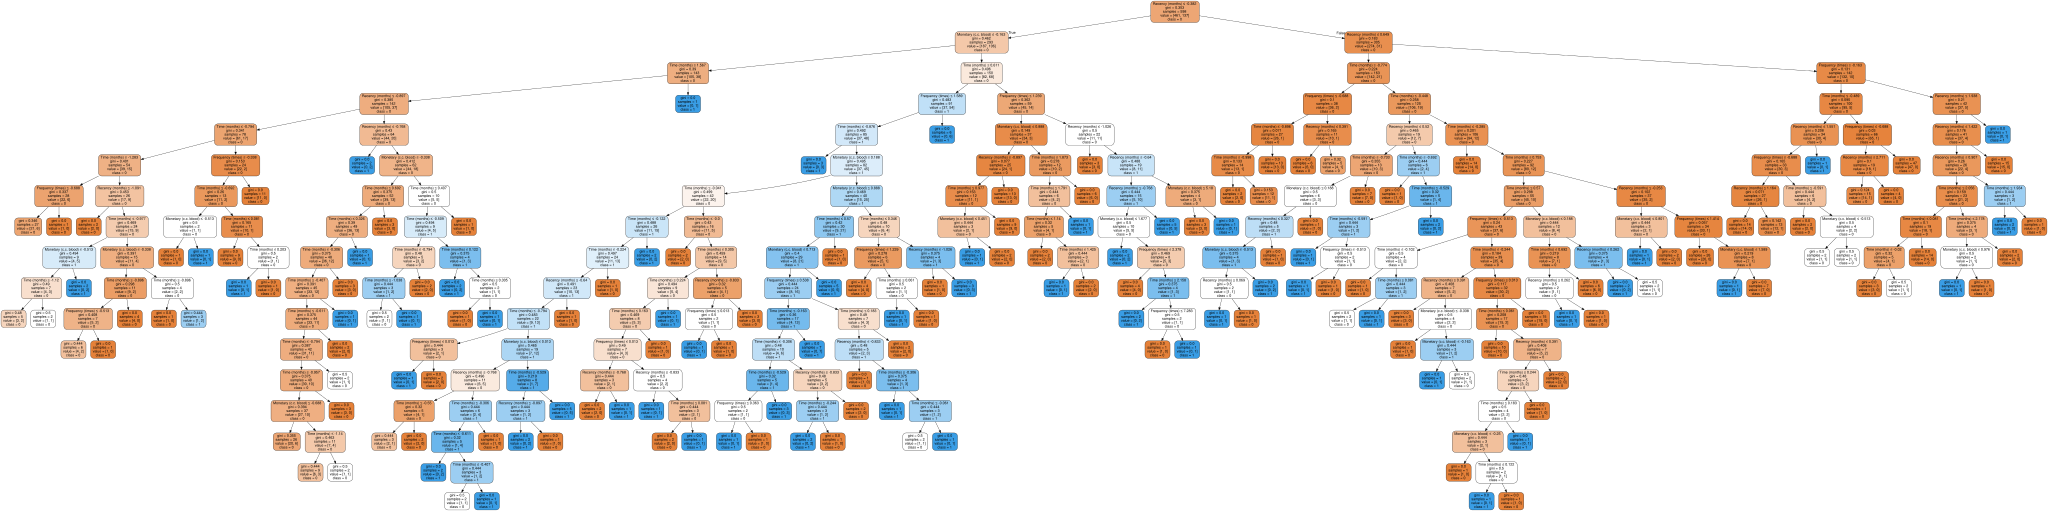

In [25]:
dot_data = tree.export_graphviz(dtree, out_file=None, 
                       feature_names=features,  
                       class_names=target_names,  
                       filled=True, rounded=True,
                       impurity=True,
                       special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

According to the decision tree, the final "splits" of the tree always occur with the attribute 'Time(months)', therefore, this feature will be used to predict the response variable. However, notice something else about our data and the algorithms we use below. The decision tree's results are logical because it intuitively makes sense that a person's decision to donate blood or not will be heavily dependent on when they last donated blood; blood can only be donated so often, often every 56 days (Canada Blood ...............................). Understanding the dataset and its domain knowledge proves to be invaluable in deciphering algorithm result correctness.

**However since the rest of the classification algorithms taught in the course do allow multiple independent variables, it is possbile to keep more features. This dataset (unlike the dataset used in our regression analysis) is relatively small and the decision tree shows the splits show that some of the nodes split on 'recency' or 'frequency' as the final attribute, not time, This shows that although most of the homogenous data is reached with Time(months), the other features still have significance (excluding 'Monetary' since it was the only feature to not directly lead to some leaf nodes). As a result, two variations of the matrix of features will be used.**

In [143]:
X = dataset[['Recency (months)', 'Frequency (times)', 'Time (months)']].values

## Step 6: Dimensionality Reduction

**Dimensionality reduction consists of two principles: feature selection & feature extraction. There are many methods to do each of these. 
Feature selection is best done manually using domain knowledge of the data set and research question. However there are machine learning techniques to complete the same task.
Feature Selection techniques include the two greedy approaches that search the entire attribute space (all features):**
- forward selection
- backward elimination

**And finally the cross validation technique which can be used to compare different combinations of features and observe which combinations produce the highest accuracy results. **
- score comparisions

In [144]:
from sklearn import decomposition #now import decomposition lib, PCA is defined in this library

In [145]:
#Main PCA Algorithm
pca = decomposition.PCA(n_components=2) #transform data set (this line only calculates) so you only see 1 column in array 
pca.fit(X) #now fit transformation/reduction technique
pcall = decomposition.PCA(n_components=2)
reducedmatrix = pca.transform(X) #after fitting, transform original to new data

**Note PCA does reduce the amount of features in the dataset. It is simply reducing the dimensions or components; and components != columns. Instead, reduction looks for the highest directions of least variance, this will be applied to all of our features.**

In [146]:
#Ensure that dimensionality reduction has occured, indeed only 2 columns remain
reducedmatrix.shape

(748, 2)

In [147]:
# Compare old and new visualizations

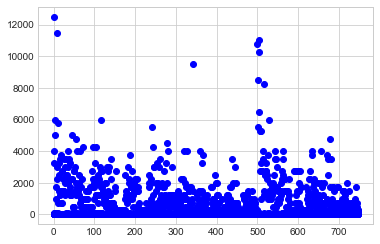

In [148]:
#Original
plt.style.use('seaborn-whitegrid')
plt.plot(dataset,'bo');

In [149]:
#Post-Dimensionality Reduction Applied

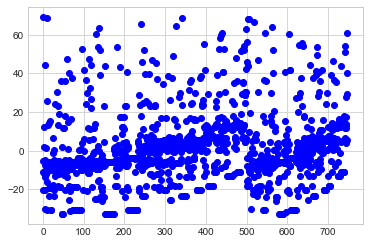

In [150]:
#Reduced
plt.style.use('seaborn-whitegrid')
plt.plot(reducedmatrix,'bo');

**Let us also **

## Step 7: a) Machine Learning Algorithms (with reduced dimensions dataset)

**To split the data set into training and testing, we start by extracting the data as numbers into a numpy array from the pandas dataframe. This is done by the '.values' function. The 'iloc' function gives us the columns which we want to extract as an inclusive range. The X variable denotes the matrix of features and contains the dependent variables which in combination predict and are associated with the y variable; the independent variable in the form of a vector.**

In [151]:
type(reducedmatrix)

numpy.ndarray

In [152]:
#np.reshape(dataset[['whether he/she donated blood in March 2007']].values, (-1, 1))
dataset[['whether he/she donated blood in March 2007']].values.flatten()

array([1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

## With our reduced data set

In [186]:
X = reducedmatrix
y = dataset[['whether he/she donated blood in March 2007']].values.flatten()
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [154]:
# The Logistic Regression Algorithm
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test) 
#Note: Its valid and usefule to also feed a list of numbers or one number into .predict() instead of a vector. 
#we want to compare all of the predicted y-values against the actual observations, so the entire vector is passed as a 
#parameter. 

y_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [155]:
y_test

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1], dtype=int64)

It's easy to see that the "1's", when a patient actually donated blood, is quite likely to be predicted incorrectly. This observation is a key reason why we need evaluation. We need a method to analyze which learning algorithm is not only the most accurate, but also what types of errors are we most likely to receive. If our true values is mostly incorrect, then we have false negative rate (a term you may be familiar with, more on this below)

### Evaluation

**Classification accuracy:** percentage of correct predictions

In [156]:
from sklearn import metrics
from __future__ import print_function
#classification accuracy of testing set for logistic regression
#TP + TN / FP + FN + TP +TN
print(metrics.accuracy_score(y_test, y_pred))

0.7219251336898396


**Null Accuracy:**anytime one uses classification accuracy, it's IMPORTANT to compare it with null accuracy; which is the accuracy that could be achieved by always predicting the most frequent class in the testing set  (predict the predominant class 100% of the time, how often will it be correct?). Or simply the probability of getting the predominant class as a percentage.

In [157]:
# calculate null accuracy (for binary classification problems coded as 0/1)
max(y_test.mean(), 1 - y_test.mean())

0.7058823529411764

*Weakness of classification accuracy #1*: It doesn't say anything about the distribution of the testing set (how many of class a was predicted correctly or class b or class d,e etc was predictedd correctly, no ratio just overall number; wouldn't you always want to know the ratio?
*Weaknesss of Classification Accuracy #2*: Observe the below results. Do you see a pattern? If you look closesly you'll notice that more 1s are incorrectly predicted than 0s. In other words, a 0 is usually predicted as a 0, but a 1 isn't as likely to be predicted as a 1; it has a higher chance of being incorrecty predicted. We can conclude that the model makes more of a certain type of error than the other. *Furthermore, glance back at the  arrays of y_pred and y_test, the True Positive rate is surprisngly low, just understanding how model's trained performance was as "poor" (the true test will be comparing not only classification accuracy, but precision and recall as well of all classification algorithms)* **To do this, we use a simple tool called the confusion matrix. It is a matrix which reveals the true positive, true negative, false positive and false negative rates found between predictions and true observations.**

In [158]:
# Compute confusion matrix
cmlogreg = metrics.confusion_matrix(y_test, y_pred)
print(cmlogreg)

[[132   0]
 [ 52   3]]


There are many metrics that can be calculated from the confusion matrix. Fortunately, the main ones are simple to calculate manually or using scikit learn library functions and reveal the distribution of what types of errors that we commonly receive.

**Precision:** When a positive value is predicted, how often is the prediction correct?

- How "precise" is the classifier when predicting positive instances?
(true yes / all true)

In [159]:
#TP / TP + FP
print(metrics.precision_score(y_test, y_pred))#scikit also has a function to do this for you 

1.0


**This is great news. The model predicts true _________________ 100% of the time FOR OUR TESTING SET. This does not mean (and is highly unlikely) that the model will have a 100% out-of-sample data recall of 100% (no model is perfect). If anything, this means we need a larger proportion of our testing set (coincidentally a strategy called cross validation iteratively splits the training and testing sets into different portions to effieciently use all observations for both).**

Sensitivity: When the actual value is positive, how often is the prediction correct?

How "sensitive" is the classifier to detecting positive instances?
Also known as "True Positive Rate" or "Recall"
(Sensitivity = true positive rate/recall because you want to know whether it calcs tp out of the BOTTOM ROW which is tp and fn since fn tells u how sensitive it is to truth (FN = in truth you have it but incorrectly predicted. The truth percentage))

In [160]:
#TP / TP + FN
print(metrics.recall_score(y_test, y_pred))#scikit has an equivalent

0.05454545454545454


**An extremely low recall score of 0.054%. We saw that almost all of our true positves (a 1 when there is a 1) were incorrectly classified as zeros. Also, the test did not have a single true negative. Our algorithm is very insensitive to correct predictions. This also shows how misleadin classification accuracy can be.**

**Conclusion: Our logistic regression had a passsable classification accuracy score of 72% However, as we saw with the other measures, this score misleads the actual poor performance. Why is the performance of the model judged to be poor you may ask? Why it is because in our research problem we are trying to find if donors donated blood. If 95% of those who donated blood are classified as those who didn't, we failed our task. This conclusion is drawn because our data set is MULTIVARIATE while our logisitic regression model is a univariate logisitic regression. We will now explore a familiar machine learning model in which we can take advantage of the other classes that also provided us information gain.**

Alternative Metric: K-Fold Cross Validation

Training accuracy rises as model complexitiy increases
and for knn model complexity is determined by k
testing accuracy penalizes overly complex or simple models
testing accuracy is highest wth right level of complexitity


The problem is train/test evaluiation scores can change alot if theres alot of
variance between the train and test data

k-fold repeates evaluation  for small train test splits several times
to overcome such variance issues, however train/test is still used for its
flexibilitty and speed (since we train test for any machine learning algo anyway, prefereably atleast)
regression = any continuos supervised machine learning
linear regression = regression for linear relationships
however, linear regression is "naive" in its assumption that the scenario can be modelled with a line

Linear Regression learns model coefficients or slopes (one for simple linear
regression, more for multiple linear regression). It learns these slopes (and
intercepts) by fitting a line that minimizes the least squares across all of the
observations. You might be asking, what does that even mean? All it means is,  that linear regression draws a line of best fit across the data, and adjusts to
perfection until the distance between any of the observations (actual data points) and the equivalent posiiton on the line (which is predicting where
those and other data points would fall) is as small as possible. This distance is totalled for all of the observations and their predicted equivalent distances; with each individual distance being squared, so that the distance is further minimized.

Bonus Evalution: Another all-in-one metric that can be substituted from classification accuracy (if you are adamant in a one metric wonder) is plotting a confusion matrix using a ROC curve.

In [164]:
# calculate cross-validated AUC
from sklearn.model_selection import cross_val_score
cross_val_score(classifier, X, y, cv=10, scoring='roc_auc').mean()

0.8836572640752207

##### The Decision Tree Algorithm (now run with dimensionality reduced & used to make predictions rather than filter features)

**IMPORTANT NOTE: We will no longer be re-splitting the data into training and testing sets or re-feature scaling. You will notice when these steps were repeated it was using different parameters of what the X really was. In the previous steps we were simple preprocessing and understanding the nuances of our data so that the model may be free of obscure features and be as reduced as possible. Now, the same scaled and reduced data will have different training algorithms run on it, to see which one is the most accurate in predicting our testing sets' observations.**

In [190]:
#Since the model is fitted with a new X_train than the one presented in step 4, another instantiation is not required
#but we do so to avoid any confusion
decisionT = DecisionTreeClassifier()
decisionT.fit(X_train,y_train)

# Predicting the Test set results
y_decisionT = decisionT.predict(X_test) 

#Again, print outy_decisionT to see how it compares to y_test before we evalute classifiers (at this point we can trust our 
#classifier functions but it helps see the results "visually" of the difference in correct vs incorrect predictions when all
#information providing features are used instead of an oversimplified correlation)
print(y_decisionT)
print(y_test)

[1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1]
[0 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 1 0
 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0
 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0
 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1]


### Even without evaluation, we can already see how much better suited the decision tree algorithm is for this data set then logistic regression. Logistic regression's probabilitistic nature (which may not translate to real life well, since this is trying to explain human behaviour; a not exactly easy task)

In [166]:
# The Naive Bayes Algorithm
from sklearn.naive_bayes import GaussianNB
bayes = GaussianNB()
bayes.fit(X_train, y_train)

# Predicting the Test set results
y_bayes = bayes.predict(X_test)

In [168]:
# The K-Nearest Neighbors (KNN) Classification Algorithm
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_knn = knn.predict(X_test)

In [170]:
# The Support Vector Machine (SVM) Algorithm
from sklearn.svm import SVC
svm = SVC(kernel = 'linear', random_state = 0)
svm.fit(X_train, y_train) 
y_svm = svm.predict(X_test)

In [172]:
# The Multi-Layer Perceptron (MLP) Classifier Algorithm
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=1)
clf.fit(X_train, y_train)
y_mlp = clf.predict(X_test)

## Step 7 b) Evaluation

Every machine learning algorithm makes mistakes, and no model is perfect. This is why there is a plethora of learning models
that exist, so we can use the best on for that scenario. However, many times, which one is best is unclear. Without a procedure
to evaluate each algorithm, we can't know which algorithms would give us the best performance or accuracy for a given dataset or 
research problem. 

Fortunately, there are built-in libraries, and tried-tested methods which can do exactly that, provide an unbiased and quantitative
evaluation for which model gives the best results for our specific dataset. This is aptly called evaluation, and different procedures
exist so that we can choose a suitable method of evaluation, just as we can choose a suitable method of machine learning. However,
note that this evaluation can only be done for supervised learning problems. For unsupervised learning algorithms such as clustering,
no evaluation is possible; given the nature of the learning. Since the goals of unsupervised learning is exploratory analysis, to discover
something which is currently unknown, there can be no metric to judge something we don't know.

Evaluation can either be performed using a train/test split of the data, or using cross-validation, or for classification
problems, the classification accuracy tecnique found in python's scikit learn (not as robust as the former two methods,
we will see why later). Whenever you split your datasetinto a training and testing partition, you are automatically performing 
a type of evaluation. Train test split has two evaluation proccedures; one for regression algorithms, and one for classification algorithms. **Regression evaluation**: procedures include the RMSE (Root Mean Squared Error), MSE (Mean Squared Error) and MOE. We will explore all of these and see which one provides the most accurate and realistic results. **Classification evaluation**: 
procedures include ROC curve analysis, CAP curve analysis, and confusion matricies. We will use confusion matricies (a prerequisite to ROC) and ROC as that is the standard validation tool used for classification metrics.

In [207]:
# Making the Confusion Matrix (we already made a confusion matrix for logistic regression)
cmbayes = metrics.confusion_matrix(y_test, y_bayes)
cmdecision = metrics.confusion_matrix(y_test, y_decisionT)
cmknn = metrics.confusion_matrix(y_test, y_knn)
cmsvm = metrics.confusion_matrix(y_test, y_svm)
cmmlp = metrics.confusion_matrix(y_test, y_mlp)
print(cmlogreg,"\n", cmbayes,"\n", cmdecision, "\n", cmknn,"\n", cmsvm,"\n", cmmlp) #all printed

[[132   0]
 [ 52   3]] 
 [[128   4]
 [ 46   9]] 
 [[113  19]
 [ 39  16]] 
 [[119  13]
 [ 32  23]] 
 [[132   0]
 [ 55   0]] 
 [[123   9]
 [ 33  22]]


Classification Accuracy (in order to compare these multiple algorithms with simplicity and not be overwhelmed with numbers, we will not be computing null accuracy for the remaining algorithms)

In [208]:
print(metrics.accuracy_score(y_test, y_bayes))
print(metrics.accuracy_score(y_test, y_knn))
print(metrics.accuracy_score(y_test, y_svm))
print(metrics.accuracy_score(y_test, y_mlp))
print(metrics.accuracy_score(y_test, y_decisionT))

0.732620320855615
0.7593582887700535
0.7058823529411765
0.7754010695187166
0.6898395721925134


Precision

In [209]:
print(metrics.precision_score(y_test, y_bayes))
print(metrics.precision_score(y_test, y_knn))
print(metrics.precision_score(y_test, y_svm))
print(metrics.precision_score(y_test, y_mlp))
print(metrics.precision_score(y_test, y_decisionT))

0.6923076923076923
0.6388888888888888
0.0
0.7096774193548387
0.45714285714285713


C:\Users\Primary\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


Recall/Sensitivity

In [210]:
print(metrics.recall_score(y_test, y_bayes))
print(metrics.recall_score(y_test, y_knn))
print(metrics.recall_score(y_test, y_svm))
print(metrics.recall_score(y_test, y_mlp))
print(metrics.recall_score(y_test, y_decisionT))

0.16363636363636364
0.41818181818181815
0.0
0.4
0.2909090909090909


### Again, we are trying to predict human behaviour. The warnings of ill-definition are because the models have no true negatives. Different algorithms take first place at different times, but knn, mlp and decision tree show greater accuracy consistently over naive bayes, svm or logisitic regression.

### Step 7 Learning & Evaluation without dimensionality reduction

In [211]:
X = dataset[['Recency (months)', 'Frequency (times)', 'Time (months)']].values
y = dataset[['whether he/she donated blood in March 2007']].values.flatten()
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

C:\Users\Primary\Anaconda3\lib\site-packages\sklearn\utils\validation.py:475: DataConversionWarning: Data with input dtype int64 was converted to float64 by StandardScaler.
  warnings.warn(msg, DataConversionWarning)


In [223]:
# The Logistic Regression Algorithm
classifierv2 = LogisticRegression(random_state = 0)
classifierv2.fit(X_train, y_train)
y_predv2 = classifierv2.predict(X_test)

In [224]:
# The Decision Tree  Algorithm
decisionTv2 = DecisionTreeClassifier()
decisionTv2.fit(X_train,y_train)
y_decisionTv2 = decisionTv2.predict(X_test) 

In [225]:
# The Naive Bayes Algorithm
bayesv2 = GaussianNB()
bayesv2.fit(X_train, y_train)
y_bayesv2 = bayesv2.predict(X_test)

In [226]:
# The K-Nearest Neighbors (KNN) Classification Algorithm
from sklearn.neighbors import KNeighborsClassifier
knnv2 = KNeighborsClassifier(n_neighbors=5)
knnv2.fit(X_train, y_train)
y_knnv2 = knnv2.predict(X_test)

In [227]:
# The Support Vector Machine (SVM) Algorithm
from sklearn.svm import SVC
svmv2 = SVC(kernel = 'linear', random_state = 0)
svmv2.fit(X_train, y_train) 
y_svmv2 = svmv2.predict(X_test)

In [228]:
# The Multi-Layer Perceptron (MLP) Classifier Algorithm
from sklearn.neural_network import MLPClassifier
clfv2 = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=1)
clfv2.fit(X_train, y_train)
y_mlpv2 = clfv2.predict(X_test)

In [229]:
# Making the Confusion Matrix (we already made a confusion matrix for logistic regression)
cmlogregv2 = metrics.confusion_matrix(y_test, y_predv2)
cmdecisionv2 = metrics.confusion_matrix(y_test, y_decisionTv2)
cmbayesv2 = metrics.confusion_matrix(y_test, y_bayesv2)
cmknnv2 = metrics.confusion_matrix(y_test, y_knnv2)
cmsvmv2 = metrics.confusion_matrix(y_test, y_svmv2)
cmmlpv2 = metrics.confusion_matrix(y_test, y_mlpv2)
print(cmlogregv2,"\n", cmbayesv2,"\n", cmknnv2,"\n", cmsvmv2,"\n", cmmlpv2)

[[129   3]
 [ 50   5]] 
 [[128   4]
 [ 46   9]] 
 [[119  13]
 [ 32  23]] 
 [[132   0]
 [ 55   0]] 
 [[123   9]
 [ 33  22]]


In [230]:
print(metrics.accuracy_score(y_test, y_predv2))
print(metrics.accuracy_score(y_test, y_bayesv2))
print(metrics.accuracy_score(y_test, y_decisionTv2))
print(metrics.accuracy_score(y_test, y_knnv2))
print(metrics.accuracy_score(y_test, y_svmv2))
print(metrics.accuracy_score(y_test, y_mlpv2))
print(metrics.accuracy_score(y_test, y_decisionTv2))

0.7165775401069518
0.732620320855615
0.6898395721925134
0.7593582887700535
0.7058823529411765
0.7754010695187166
0.6898395721925134


In [231]:
print(metrics.precision_score(y_test, y_predv2))
print(metrics.precision_score(y_test, y_bayesv2))
print(metrics.precision_score(y_test, y_decisionTv2))
print(metrics.precision_score(y_test, y_knnv2))
print(metrics.precision_score(y_test, y_svmv2))
print(metrics.precision_score(y_test, y_mlpv2))
print(metrics.precision_score(y_test, y_decisionTv2))

0.625
0.6923076923076923
0.4634146341463415
0.6388888888888888
0.0
0.7096774193548387
0.4634146341463415


C:\Users\Primary\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


In [232]:
print(metrics.recall_score(y_test, y_predv2))
print(metrics.recall_score(y_test, y_bayesv2))
print(metrics.recall_score(y_test, y_decisionTv2))
print(metrics.recall_score(y_test, y_knnv2))
print(metrics.recall_score(y_test, y_svmv2))
print(metrics.recall_score(y_test, y_mlpv2))
print(metrics.recall_score(y_test, y_decisionTv2))

0.09090909090909091
0.16363636363636364
0.34545454545454546
0.41818181818181815
0.0
0.4
0.34545454545454546


** Some metrics show increases in accuracy, while some show decreases. However, more algorithms better fitted without dimensionality reduction. We can attribute this to the small dataset and the real life conditions.**

# Comparision of Regression Algorithms on an Entire Machine Learning Process

 ##  Preprocessing

## Step 1-Regression: Read the Data

In [233]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('parkinsons.csv') 

## Step 2-Regression: Type Checking

In [234]:
df.tail()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
5870,42,61,0,142.79,22.485,33.485,0.00406,0.000031,0.00167,0.00168,...,0.160,0.00973,0.01133,0.01549,0.02920,0.025137,22.369,0.64215,0.55314,0.21367
5871,42,61,0,149.84,21.988,32.988,0.00297,0.000025,0.00119,0.00147,...,0.215,0.01052,0.01277,0.01904,0.03157,0.011927,22.886,0.52598,0.56518,0.12621
5872,42,61,0,156.82,21.495,32.495,0.00349,0.000025,0.00152,0.00187,...,0.244,0.01371,0.01456,0.01877,0.04112,0.017701,25.065,0.47792,0.57888,0.14157
5873,42,61,0,163.73,21.007,32.007,0.00281,0.000020,0.00128,0.00151,...,0.131,0.00693,0.00870,0.01307,0.02078,0.007984,24.422,0.56865,0.56327,0.14204
5874,42,61,0,170.73,20.513,31.513,0.00282,0.000021,0.00135,0.00166,...,0.171,0.00946,0.01154,0.01470,0.02839,0.008172,23.259,0.58608,0.57077,0.15336


In [235]:
type(df)

pandas.core.frame.DataFrame

In [236]:
df.shape

(5875, 22)

In [237]:
type(df['total_UPDRS'])

pandas.core.series.Series

In [238]:
#confirm where the column indexing begins
df.columns[0]

'subject#'

## Step 3-Regression Visualize The Data before Preprocessing

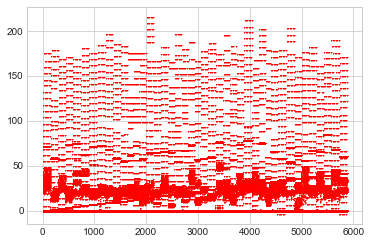

In [239]:
plt.style.use('seaborn-whitegrid')
plt.plot(df,'r+',linewidth=1, markersize=1); #additional parameters decrease plot size for better visual of distribution

## Step 4-Regression: Exploratory Analysis

In [240]:
from sklearn.cluster import KMeans

Instantiate a kmeans object and choose a value of k. Since we have two class variables of the response/target feature, we will choose a value of two; so two clusters.

The # of clusters to choose in this instance is more challenging; chose 8 as a larger K often produces more accurate clusters
due to the fact that the distances between all observations within a cluster and its centroids is minimized.
- Given the size of the dataset, k=8 seems reasonable
- Parameter tuning could be also be performed here, but we will use our tuning experience from the previous labs to estimate

In [241]:
kmeans = KMeans(n_clusters=8)

Now let us identfiy the dataset's into a matrix of features and an independent vector (same as with classification). Since clustering algorithms are unsupervised learning, we will not use train/test split. **From reading the dataset descriptions it was learned that this dataset is has not one, but two response variables (multivariate). The two response variables are 'total_UPDRS' and 	'motor_UPDRS'; since total_UPDRS' values also contain the motor_UPDRS values, it is logical to eliminate the latter. (SEE PAIR WISE PLOTS; BOTH CORRELEATE EQUALLY WITH FEATURES) However, this conclusion is better reached after viewing the clustering results; the exploratory analysis will better aid this decision.** Since the response variables are in the middle, they must be indexed as so.

In [242]:
X = df[['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP','Shimmer','Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5', 'Shimmer:APQ11','Shimmer:DDA','NHR', 'HNR',
            'RPDE', 'DFA', 'PPE']].values
#pandas instead of numpy for convinience of operations
#pdX = df[['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
            #'Shimmer','Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5', 'Shimmer:APQ11','Shimmer:DDA','NHR', 'HNR',
            #'RPDE', 'DFA', 'PPE']]
y = df[['motor_UPDRS','total_UPDRS']].values
#pdy = df[['motor_UPDRS','total_UPDRS']]

In [243]:
kmeans.fit(X)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=8, n_init=10, n_jobs=1, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

We can see in the parameters output that kmeans++ was ran by default and 2 clusters for formed. (Kmeans++ having run means that the algorithm is repeated to ensure that our choice of k doesn't fall into the random intialization trap)

Let's print out the centroids and labels.

In [244]:
kmeans.cluster_centers_

array([[3.03642757e+01, 6.35991561e+01, 4.14908579e-01, 4.88067595e+01,
        6.66185654e-03, 4.55869761e-05, 3.28869198e-03, 3.62336146e-03,
        9.86609001e-03, 3.63463150e-02, 3.30424754e-01, 1.78405485e-02,
        2.15536006e-02, 3.00862869e-02, 5.35208861e-02, 3.65824304e-02,
        2.10118397e+01, 5.50432686e-01, 6.66948734e-01, 2.30077668e-01],
       [3.24533333e+01, 6.46681481e+01, 4.40000000e-01, 1.31624504e+02,
        6.69490370e-03, 4.61094519e-05, 3.19626667e-03, 3.71960000e-03,
        9.58909630e-03, 3.78649778e-02, 3.43605926e-01, 1.87925333e-02,
        2.24967852e-02, 3.05564889e-02, 5.63780889e-02, 4.23449289e-02,
        2.08284119e+01, 5.54113348e-01, 6.55505941e-01, 2.30873419e-01],
       [2.08441558e+01, 6.48664193e+01, 3.19109462e-01, 1.92245687e+01,
        6.27802412e-03, 4.37627180e-05, 3.06151206e-03, 3.33549165e-03,
        9.18455473e-03, 3.49711410e-02, 3.19280148e-01, 1.75276531e-02,
        2.08274675e-02, 2.86853154e-02, 5.25827365e-02, 3.3975

The distances are not overly large. So it seems the clustering is well perfomed.

In [245]:
kmeans.labels_

array([2, 2, 2, ..., 3, 3, 3])

Remember that the labels are numerical and continous now.

#### Now we will also perform hierarichal clustering. With two types of clustering algorithms, we will have a very accurate breakdown of our model's clusters.

In [246]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
#We can either use single linkage (euclidean distance of the closest points of the clusters in the dendrogram)
#or complete linkage (distance of furthest points of the clusters in the dendrogram)
mergings = linkage(X, method='single') #chose single linkage #pass in our matrix of features as the first parameter
#and what HC will merge on (we are using agglomerative HC)

Plot the result of HC, our dendrogram. However, recall that in order to run HC, we need a scaled dataset. We discovered in steps 2-3, that our dataset was not scaled. Let us first run feature scaling and then plot the dendrogram of HC.

In [247]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

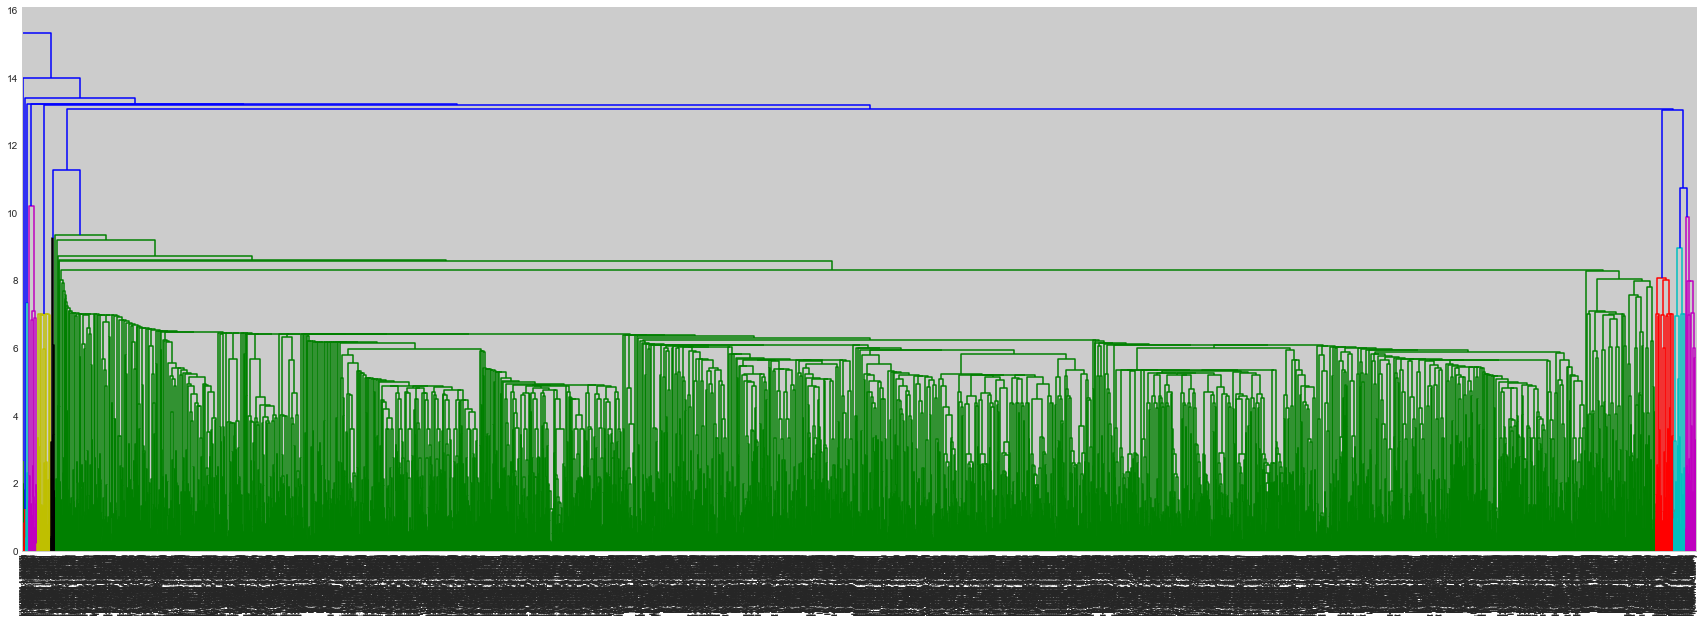

In [248]:
plt.figure(figsize=(30, 10))
dendrogram(mergings,
           labels=y,
)
plt.show()

It is not necessary to also run HC and fit the model on our data set. The goal of this stage was simply to explore our data, and the dendrograms as well as kmeans_labels functions did exactly that. Now, it is time to move on to the next step, in which we will try to reduce the features of our dataset and any noise that accompanies features which do not add to the analysis or have any impact on the correleations.**Also note, this is a good example of understanding why certain algorithms are better suited for others. One of HC's weaknesses is large datasets. Seeing as this is a large dataset we can see how even larger datasets would lose HC's benefits of visual understanding of the nested dendrogram.**

## Step 5-Regression: Feature Elimination- Reducing the noise of our data

**From reading the dataset descriptions, it was revealed that this particular dataset had two response variables-rather than one. For educational purposes, this is one of the few datasets that I could find, which was large enough to pose a greater challenge than the data set used in the classification run (since it has more attributes), but also be feasible to complete (it did not significantly slow the results or contain data that was so variant that preprocessing and analysis would be outside the scope of this assignment). As a result, since one of the response variables is just an ... I chose to eliminate it from the dataset. Reading the rest of the dataset did not reveal any other indicative information regarding the features and correlations with the response variable. Therefore, we will apply the fast learning scheme just as it was applied in the classification run.**
The two response variables are: 'motor_UPDRS' & 'total_UPDRS'

The Fast Learning Scheme: Multiple Linear Regression

In [250]:
#remove column 'motor_UPDRS' from the dataset
df.columns

Index(['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS',
       'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
       'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'],
      dtype='object')

In [251]:
df.drop('motor_UPDRS', axis = 1, inplace=True)

In [252]:
#Confirm that feature was eliminated
df.head()

,subject#,age,sex,test_time,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,35.810,0.00528,0.000027,0.00191,0.00264,0.00573,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,36.375,0.00335,0.000020,0.00093,0.00130,0.00278,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [260]:
# Re-assign the matrix of features and independent vector (because of the exclusion of motor_UPDRS )
X = df[['subject#','age','sex','test_time','Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP','Jitter:PPQ5', 'Jitter:DDP', 
            'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR',
            'RPDE', 'DFA', 'PPE']].values
y = df.total_UPDRS.values 
y = y.reshape(-1,1)
y.shape

(5875, 1)

In [261]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [262]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)
sc_y = StandardScaler()
#y_train = y_train.reshape(-1,1)
#y_test.reshape(-1,1)
y_train = sc_y.fit_transform(y_train)

In [263]:
# Fitting Multiple Linear Regression to the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predicting the Test set results
y_pred = regressor.predict(X_test)
#NO EVALUATION, NOT RUNNING ALGORITHM TO LEARN, BUT TO REDUCE FEATURES, the evaluation of multiple linear regression will
#occur in step 7

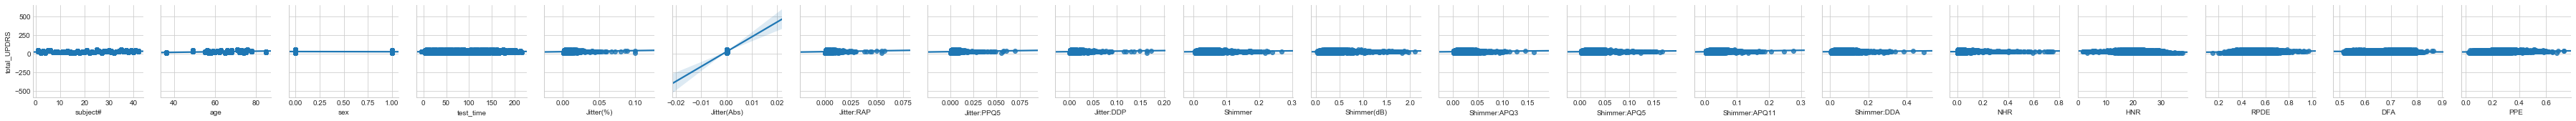

In [266]:
import seaborn as sns
# allow plots to appear within the notebook
%matplotlib inline
sns.pairplot(df, x_vars=['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
            'Shimmer','Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5', 'Shimmer:APQ11','Shimmer:DDA','NHR', 'HNR',
            'RPDE', 'DFA', 'PPE'], y_vars=['total_UPDRS'],kind='reg')

**Given the above correlations and intuition, we can eliminate some variables**

In [271]:
X = df[['test_time','Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP','Jitter:PPQ5', 'Jitter:DDP', 
            'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR',
            'RPDE', 'DFA', 'PPE']].values

## Step 6-Regression: Dimensionality Reduction

In [ ]:
from sklearn import decomposition #now import decomposition lib, PCA is defined in this library

In [272]:
#Main PCA Algorithm
pca = decomposition.PCA(n_components=6) #transform data set (this line only calculates) so you only see 6 columns in array
pca.fit(df) #now fit transformation/reduction technique to our df
reducedset = pca.transform(df) #after fitting to df, transform original to new data

In [273]:
#Ensure that dimensionality reduction has occured, indeed only 6 columns remain but the number of instances is still the same
reducedset.shape

(5875, 6)

## Step 7-Regression Algorithms & Evaluation

In [320]:
#Resplit data
# Re-assign the matrix of features and independent vector (because of the exclusion of motor_UPDRS )
X = reducedset
y = df[['total_UPDRS']].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [321]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)
sc_y = StandardScaler()
#y_train = y_train.reshape(-1,1)
#y_test.reshape(-1,1)
y_train = sc_y.fit_transform(y_train)

In [322]:
print(X_train.shape)
print(X_test.shape)

(4700, 6)
(1175, 6)


In [323]:
#Fit Multiple Linear Regression
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Predicting the Test set results
y_mlr = mlr.predict(X_test)
#y_mlr = sc_y.inverse_transform(y_mlr)

### Last section inverse transformation was not applied because the predictions and test class variables were binary. Now, in order to interpret our results, we must apply them.

In [324]:
# Fit SVR
from sklearn.svm import SVR
svr = SVR(kernel = 'rbf')
svr.fit(X, y)

# Predicting test set result
y_svr = svr.predict(X_test)
#y_svr = sc_y.inverse_transform(y_pred)

C:\Users\Primary\Anaconda3\lib\site-packages\sklearn\utils\validation.py:578: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [325]:
y_svr

array([28.10586232, 28.10601416, 28.10399421, ..., 28.10575647,
       28.10592196, 28.10388735])

In [326]:
#Re-feature scale for our evaluations, above was an example for interpreting actual predictions
y_svr = svr.predict(X_test)

##### Parameter Tuning: A Consideration (Literature)
Often we are not satisfied with the results of our algorithm; or we think we can do better. **Here, in our scenario, we may wish to adjust which k would be suitable for our algorithm**. So, to remedy this we can different k-values of KNN. Now you may wonder, how can we possibly try every single value. The good news is we don't have to, k is best left to be a small positive integer. However, small may be relative to the size of your dataset. Fortunately, python isn't just a data science tool, but a full fledged programming language as well, we can loop through several k-value candidates using python's range function, and then plot the results.

In [327]:
# Fit KNN Regression
from sklearn.neighbors import KNeighborsRegressor
knnregressor = KNeighborsRegressor(n_neighbors=6)
knnregressor.fit(X, y) 
y_knnr = knnregressor.predict(X_test)
#y_knnr = sc_y.inverse_transform(y_knnr)

**EVALUATION**

Regressions algorithms are parametric and use forumulas to output continous values. There are no true or false, only continous variables. Therefore, classification metrics based on confusion matricies or ROC/AUC are not applicable. Instead, we use the concept of the cost function; in other words we evaluate models based on how effectively they minimize residual error. Residuals are calculated by subtracting the actual observations' numeric values from the predicted values. A way to visualize this is that we are trying to minimize the displacement from the line of best fit and the actual data points. There are three metrics commonly used in regression. Note: ALL BELOW METRICS take total the (true - predicted) of all data points. However, not all utilze the concept of LEAST SQUARES. This concept simply means squaring the residual displacements so that our model is even more accurate. (see why below)
- Mean Absolute Error (MAE): A simple average of the sum of residuals. Interpretable in same units as response variable. Does not utilize the least squares regression concept.
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

Note: Since we are calculating the residual error in each case, a lower number is desired as it equates to a lower error of our predictive model's capabilities.

In [328]:
# calculate RMSE using scikit-learn
print(np.sqrt(metrics.mean_squared_error(y_test, y_knnr)))
print(np.sqrt(metrics.mean_squared_error(y_test, y_svr)))
print(np.sqrt(metrics.mean_squared_error(y_test, y_mlr)))
print("\n")
# calculate MSE using scikit-learn
print(metrics.mean_squared_error(y_test, y_knnr))
print(metrics.mean_squared_error(y_test, y_svr))
print(metrics.mean_squared_error(y_test, y_mlr))
print("\n")
# calculate MAE using scikit-learn
print(metrics.mean_absolute_error(y_test, y_knnr))
print(metrics.mean_absolute_error(y_test, y_svr))
print(metrics.mean_absolute_error(y_test, y_mlr))

10.650139196699062
10.594731874031714
30.558076120018693


113.42546490906572
112.24834348262357
933.7960161568567


8.43176275177305
8.44168645043229
29.01951038842555


### Step 7 Learning & Evaluation without dimensionality reduction

In [338]:
X = df[['test_time','Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP','Jitter:PPQ5', 'Jitter:DDP', 
            'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR',
            'RPDE', 'DFA', 'PPE']].values
y = df[['total_UPDRS']].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [339]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)
sc_y = StandardScaler()
#y_train = y_train.reshape(-1,1)
#y_test.reshape(-1,1)
y_train = sc_y.fit_transform(y_train)

In [340]:
#Fit Multiple Linear Regression
from sklearn.linear_model import LinearRegression
mlrv2 = LinearRegression()
mlrv2.fit(X_train, y_train)

# Predicting the Test set results
y_mlrv2 = mlrv2.predict(X_test)
#y_mlr = sc_y.inverse_transform(y_mlr)

In [341]:
# Fit SVR
from sklearn.svm import SVR
svrv2 = SVR(kernel = 'rbf')
svrv2.fit(X, y)

# Predicting test set result
y_svrv2 = svrv2.predict(X_test)
y_svrv2 = sc_y.inverse_transform(y_pred)

C:\Users\Primary\Anaconda3\lib\site-packages\sklearn\utils\validation.py:578: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [343]:
# Fit KNN Regression
from sklearn.neighbors import KNeighborsRegressor
knnregressorv2 = KNeighborsRegressor(n_neighbors=6)
knnregressorv2.fit(X, y) 
y_knnrv2 = knnregressorv2.predict(X_test)
y_knnrv2 = sc_y.inverse_transform(y_knnrv2)

**EVALUATION**

In [347]:
# calculate RMSE using scikit-learn
print(np.sqrt(metrics.mean_squared_error(y_test, y_knnrv2)))
print(np.sqrt(metrics.mean_squared_error(y_test, y_svrv2)))
print(np.sqrt(metrics.mean_squared_error(y_test, y_mlrv2)))
print("\n")
# calculate MSE using scikit-learn
print(metrics.mean_squared_error(y_test, y_knnrv2))
print(metrics.mean_squared_error(y_test, y_svrv2))
print(metrics.mean_squared_error(y_test, y_mlrv2))
print("\n")
# calculate MAE using scikit-learn
print(metrics.mean_absolute_error(y_test, y_knnrv2))
print(metrics.mean_absolute_error(y_test, y_svrv2))
print(metrics.mean_absolute_error(y_test, y_mlrv2))

296.71811706556633
9.25163631812472
30.85874476840789


88041.64099493512
85.59277456284434
952.2621286817414


296.52994437332836
7.489860490648557
29.02910122385734


# Conclusion

For our regression dataset, which was significantly larger, we see an decrease in errors for RMSE and the others. This shows that dimensionality reduction is effective; our previous classification dataset was too small to have an effect. However, given the odd values perhaps are parameters of passed components were inaccurate or the dataset is still smaller than what size is intended for PCA. To improve this, we should consider cross validation and parameter tuning for superior model selection. Cross validation was not chosen for feature selection before due to the large amount of features in the regression dataset. For classification, the decision tree algorithm is superior as it provides information gain values. Purity bits and entropy is a quanitifiable and accurate method for feature learning. Cross validation's trial and error appraoches pale in comparision.

#### Questions To TroubleShoot Inaccurate Predictions
- Are there any assumptions that the model makes which are incompatible with my data? (Is my data set the wrong size for this type of algorithm? Are there too many outliers? Curvilinear?)
- Is the data the correct type for this model?
- Is there any parameter tuning that could be done to better optimize the functions of the object? (Not always an option, ex. regression cannot have parameters tuned, but some algorithms, such as KNN or SVM or other classifiers can greatly benefit from this step)
- Does my data have any noise which could be reduced or be completely changing the aspect of the algorithms "runs"? Can any features be eliminated so that noise is reduced but the dataset still contains all of the information?
- Perhaps the results are correct but simply scrambled, can I reduce the dimensions of the dataset to overcome this issue?
- Does all of the data follow the same scale/magnitude of numbers? Should I apply feature scaling if I haven't already? 
- If all of the above fail, then perhaps its time to try a different machine learning algorithm, or revise your research question. 
- Evaluate your algorithm using either train/test evaluation metrics from scikit learn or k-fold cross validation
	Check the accuracy score or error percentage you obtain. Are you satisfied with this? If not see the questions posed in the previous step ("Questions To TroubleShoot Inaccurate Predictions").

**Machine Learning Evaluation: Some Additioinal Notes**

Classficaiton accuracy (aka training accuracy because we are testing the model on the same data on which we
trained the model) searches for the ratio of correct predictions. It is a common evaluation metric but, 
as you can guess, is not the best due to the fact it is using the same data set used for training. This
means it may be victim to overfitting errors, and provide a optimistic and overly-confident accuracy, which is not
in fact true. Classification accuracy can be checked simply by:
- import the library
- call accuracy_score function of metrics class
- pass in the true observations and the predicted observations

This can be used for all KNN classification, Logisitic Regression, etc
isnt hard for softwaare to memorize, imagine knn = 1, how meaningful is a classification accuracy there?
High training accuracy is useless, in overfitted models the algorithms have memorised the noise and are complex for all the wrong reasons. 

Review of procedure:
- import the dataset
- visualize the data to get a feel for it
- check type (so we know which data structure the data is held in)  convert to pandas dataframe, there are other options, but python's pandas library is a great and widely used tool that 
- print either your entire dataset, or .head() and .tail() to show the first 5 and last 5 records respectively
- ask yourself, what are the features, what do they represent? Which column is the target or response attribute? Is the response attribute discrete or continuous, text or numerical? Decide if you will use regression or classification. What does each record signify? (ex 200 cancer patients, 400 employees that took time off in December, etc)
- split into training/testing
- transform data (feature scale, transform test data into same shape)
- check the shape of dataset (to know dimensionality and verify how the testing and training was split) ex. print X_train.shape 
- Apply algorithm 
- inverse scale (reverse back to original). Since you're predictions were with transformations, but response variable that was observed at the beginning of the procedure was not. In order for our predictions to be interpretable in the same units as the response variable, they must be in the same magnitude- and the magnitude is altered during feature scaling (otherwise you would be scratching your head thinking my predictions are non-sensical when in reality they have been transformed

#### Applying the Machine Learning Algorithm
- Instantiate an object of the algorithms's class
- Call the "fit" method of the object, this is where the learning occurs, the object is the machine which learns the correleations or patterns of the training data set. It gathers information from the raw data.
- Make predictions on the testing set, this will tell us if the machine has learned anything new or simply
  just memorized the patterns of the training set. Do this by calling the predict method of the object and passing
  your testing partition of the data as the parameters. The output of this function will be the predictions that the
  object (your model) makes on the dependent matrix of features, or in other words, the independent values or the 
  target feature. Compare the values of y_pred with y_test.
- If in this step you discover that the machine has not learned effectively, then you may want to revise your steps and choice of the algorithm. (we explore questions on how to troubleshoot this below)